In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import joblib
from sklearn.model_selection import ParameterGrid
from tqdm.auto import tqdm

import os
import sys
sys.path.append('../')
import src.forecasting.simulations      as sim
import src.fda.kde.estimators           as kde

In [174]:
EXECUTION_DATE : str = datetime.now().strftime('%Y%m%d')
LOG_PATH       : str = f'../logs/simulations/{EXECUTION_DATE}.log'
FILES_PATH     : str = f'../data/interim/simulation/{EXECUTION_DATE}/'
DATABASES_PATH : str = f'../data/interim/simulation/{EXECUTION_DATE}/databases/'
ALL_KDES_PATH  : str = f'../data/interim/simulation/{EXECUTION_DATE}/all_kdes.jbl'
CV_FILES_PATH  : str = f'../data/interim/simulation/{EXECUTION_DATE}/progress/'

Path(FILES_PATH).mkdir(parents=True, exist_ok=True)
Path(DATABASES_PATH).mkdir(parents=True, exist_ok=True)
Path(CV_FILES_PATH).mkdir(parents=True, exist_ok=True)

Let $\lbrace u\mapsto g(u\mid \theta; \pi) : \theta\in\Theta, \pi\in\Pi\rbrace$ be a parametric family of (deterministic) densities with parameter space $\Theta\times\Pi$, where $\Theta\subseteq\mathbb{R}^k$. 

For fixed (deterministic) model parameters $\pi\in\Pi$, $\theta^*\in \Theta$, and $k\times k$ matrices $\alpha$ and $\beta$, plus a user supplied parameter $\gamma\in\lbrace0, 1/2, 1\rbrace$, consider the model given by the following dynamic equations

\begin{equation}
\mathcal{Z}_{t-1} = \sigma(Z_s : s\leq t-1)
\end{equation}

\begin{equation}
\mathbb{P}(Z_{t}\leq z\mid \mathcal{Z}_{t-1}) = \int_{-\infty}^{z} f_t(z)\,\mathrm{d}z,\qquad f_t(z):=g(z\mid \vartheta_t;\pi)
\end{equation}

\begin{equation}
\vartheta_{t+1} - \theta^* = \alpha\, (\mathbb{E}[\nabla_t\nabla_t^{\intercal}\mid \mathcal{Z}_{t-1}]^{-\gamma}\,\nabla_t) + \beta\, (\vartheta_{t} - \theta^*)
\end{equation}

where

\begin{equation}
\nabla_t = \left.\frac{\partial \log g(u\mid\theta;\pi)}{\partial \theta}\right|_{u=Z_t,\ \theta=\vartheta_t}
\end{equation}

\begin{equation}
\vartheta_t = (m_t, \ell_t, \eta_t) = (mean_t, log(std_t), log(asymmetry_t))
\end{equation}

In [157]:
# Define scenarios
gas_params = {
    "scenario_1": {
        "alpha": np.diag([0.20, 0.02, 0.01]),
        "beta": np.diag([0.40, 0.95, 0.90]),
    },
    "scenario_2": {
        "alpha": np.diag([0.005, 0.005, 0.005]),
        "beta": np.diag([0.99, 0.99, 0.99]),
    },
    "scenario_3": {
         "alpha": np.diag([0.03, 0.02, 0.015]),
          "beta": np.diag([0.95, 0.90, 0.85])
    }
}

distribution_params = {
    "nu": [3, 5, 8]
}

In [160]:
from itertools import product

keys = ["scenario", "nu"]
values = [list(gas_params.keys()), distribution_params["nu"]]

param_grid = []

for scenario, nu in product(*values):
    gas_cfg = gas_params[scenario]

    param_grid.append({
        "scenario": "___nu=".join([scenario, str(nu)]),
        "nu": nu,
        "alpha": gas_cfg["alpha"],
        "beta": gas_cfg["beta"]    
})

In [193]:
x = np.linspace(-10, 10, 5001)
N_REPS = 100
T = 300
N_SAMPLES = 288
total = len(param_grid) * N_REPS

sim_database = {}
progress = 0

for params in param_grid:
    scenario = params["scenario"]
    # Initialize scenario level
    sim_database[scenario] = {
        "params": params,
        "replications": {}
    }
    
    for n_rep in range(N_REPS):
        # 1. Setup Model and Simulate
        gm = sim.GasModel(alpha=params["alpha"], beta=params["beta"], nu=params["nu"])
        sim_results = gm.simulate(T=T)
        
        # 2. Get Theoretical Densities
        sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])
        dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=T, freq="D")
        sim_density.columns = dates
        
        # 3. Generate Samples Efficiently
        # Collect arrays first, then create DataFrame once
        samples_list = []
        for i in range(len(sim_results["theta"])):
            # Draw n samples for the theta at time i
            sample = gm.rvs(n=N_SAMPLES, theta=sim_results["theta"][i])
            samples_list.append(sample)
        
        # Create DataFrame: each column is a time step, each row a sample
        df_samples = pd.DataFrame(np.array(samples_list).T, columns=dates)
        
        # 4. Store in Database
        sim_database[scenario]["replications"][n_rep] = {
            "theta": sim_results["theta"],
            "densities": sim_density,
            "samples": df_samples
        }

        progress += 1
        if progress % 10 == 0: # Print less frequently to keep console clean
            print(f"Progress: {progress}/{total}")

Progress: 10/900
Progress: 20/900
Progress: 30/900
Progress: 40/900
Progress: 50/900
Progress: 60/900
Progress: 70/900
Progress: 80/900
Progress: 90/900
Progress: 100/900
Progress: 110/900
Progress: 120/900
Progress: 130/900
Progress: 140/900
Progress: 150/900
Progress: 160/900
Progress: 170/900
Progress: 180/900
Progress: 190/900
Progress: 200/900
Progress: 210/900
Progress: 220/900
Progress: 230/900
Progress: 240/900
Progress: 250/900
Progress: 260/900
Progress: 270/900
Progress: 280/900
Progress: 290/900
Progress: 300/900
Progress: 310/900
Progress: 320/900
Progress: 330/900
Progress: 340/900
Progress: 350/900
Progress: 360/900
Progress: 370/900
Progress: 380/900
Progress: 390/900
Progress: 400/900
Progress: 410/900
Progress: 420/900
Progress: 430/900
Progress: 440/900
Progress: 450/900
Progress: 460/900
Progress: 470/900
Progress: 480/900
Progress: 490/900
Progress: 500/900
Progress: 510/900
Progress: 520/900
Progress: 530/900
Progress: 540/900
Progress: 550/900
Progress: 560/900
P

In [194]:
joblib.dump(sim_database, f"{FILES_PATH}simulation_database.jbl")

['../data/interim/simulation/20260503/simulation_database.jbl']

In [177]:
# model = 'scenario_1___nu=3'
# print(sim_database[model]["params"])
# sim_database[model][10]["densities"].iloc[:,:2].plot(figsize=(15,5))
# sim_database[model][10]["samples"].iloc[:,:2].plot(kind="hist", density=True, bins=30, figsize=(15,5), alpha=.5)

In [197]:
# KDE params
# t_dfs = range(3,6)
t_dfs = [3]

# rot_grid = {
#     "method": ["rot"],
#     "kernel": ["gaussian"],
#     # "sigma_robust": [True, False]
# }

adaptive_grid = {
    "method": ["adaptive"], 
    "kernel": ["gaussian"]
}

adaptive_grid_t = {
    "method": ["adaptive"], 
    "kernel": ["t-student"],
    "df": [df for df in t_dfs],
}


density_param_grid = {}
for grid in [adaptive_grid, adaptive_grid_t]:
    for params in ParameterGrid(grid):
        
        key_parts = [params["kernel"]]
        if "method" in params: key_parts.append(params["method"])
        if "df" in params: key_parts.append(f"df={params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        full_model_name = "_".join(key_parts).replace(".", "")
        
        kernel_label = params["kernel"]
        if "df" in params:
            kernel_label += f"+df={params['df']}"
            
        bw_label = params.get("method", "fixed")
        if params.get("sigma_robust"): bw_label += "_robust"
        if params.get("cv") == "LOO": bw_label += "_loo"


        density_param_grid[full_model_name] = {
            "kernel": kernel_label,
            "bandwidth": bw_label,
            "params": params  
        }

print("KDE models:")
for name, values in density_param_grid.items():
    print("\t",name, ":", values["params"])

print(f"Total KDE models: {len(density_param_grid.items())}")

KDE models:
	 gaussian_adaptive : {'kernel': 'gaussian', 'method': 'adaptive'}
	 t-student_adaptive_df=3 : {'df': 3, 'kernel': 't-student', 'method': 'adaptive'}
Total KDE models: 2


In [ ]:
total = len(sim_database) * N_REPS * len(density_param_grid)
pbar = tqdm(total=total, desc="Total CV Progress")

kde_databases = {}
# progress = 0
for scenario, database in sim_database.items():
    print(f"Processing configuration for {database['params']}")
    kde_databases[scenario] = {}
    sim_reps_database = sim_database[scenario]["replications"]
    
    for n_rep, df in sim_reps_database.items():
        print(f"\t{n_rep}")
        returns_df = sim_reps_database[n_rep]['samples']
        kde_databases[scenario][n_rep] = {}
        
        for kde_bw_name, kde_bw_params in density_param_grid.items():
            print(f"\t simulation n. = {n_rep}: {kde_bw_name}")
            
            # bandwidths
            df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params["params"])    
            kde_params = {k: v for k, v in kde_bw_params["params"].items() if k in ['kernel', 'df']}
            
            # kdes
            df_grids, df_densities = kde.df_to_kde(
                X=returns_df, 
                h=df_h, 
                normalize_densities=False,
                **kde_params
            )

            rep_result = {
                        "scenario":     scenario,
                        "n_rep":        n_rep,
                        "model_name":   kde_bw_name,
                        "kde_params":   kde_bw_params["kernel"],
                        "kernel":       kde_bw_params["params"]["kernel"],
                        "bw_params":    kde_bw_params["bandwidth"],
                        "bw_method":    kde_bw_params["params"]["method"],
                        "df_h":         df_h,
                        "df_support":   df_grids,
                        "df_densities": df_densities
                }

            # kde_databases[scenario][n_rep][kde_bw_name] = rep_result
            
            joblib.dump(rep_result, f"{CV_FILES_PATH}{scenario}___rep_{n_rep}___kde_{kde_bw_name}.jbl")

            del df_h
            del df_grids
            del df_densities
            del kde_params

            # progress += 1
            # print(f"{progress}/{total}")
            pbar.update(1)


Total CV Progress:   0%|          | 0/1800 [00:00<?, ?it/s]

Processing configuration for {'scenario': 'scenario_1___nu=3', 'nu': 3, 'alpha': array([[0.2 , 0.  , 0.  ],
       [0.  , 0.02, 0.  ],
       [0.  , 0.  , 0.01]]), 'beta': array([[0.4 , 0.  , 0.  ],
       [0.  , 0.95, 0.  ],
       [0.  , 0.  , 0.9 ]])}
	0
	 simulation n. = 0: gaussian_adaptive


In [204]:
paths = [''.join([CV_FILES_PATH, x]) for x in os.listdir(CV_FILES_PATH)]

database = []
for path_name in paths:
    database.append(joblib.load(path_name))

In [216]:
database

[{'scenario': 'scenario_1___nu=3',
  'n_rep': 0,
  'model_name': 't-student_adaptive_df=3',
  'kde_params': 't-student+df=3',
  'kernel': 't-student',
  'bw_params': 'adaptive',
  'bw_method': 'adaptive',
  'df_h':      2025-07-08  2025-07-09  2025-07-10  2025-07-11  2025-07-12  2025-07-13  \
  0      0.338364    0.422191    0.321447    0.579447    0.512296    0.215591   
  1      0.250348    0.266301    0.226615    0.340012    0.305973    0.232956   
  2      0.332070    0.580907    0.330370    0.379866    1.396695    0.232761   
  3      0.261327    0.263855    0.278250    0.366510    0.417425    0.220487   
  4      0.749554    0.302047    0.219099    1.306990    0.416489    0.225676   
  ..          ...         ...         ...         ...         ...         ...   
  283    0.266700    0.343472    0.218114    0.329410    0.381378    0.215677   
  284    0.771622    0.316150    0.241086    0.322052    0.310687    0.259737   
  285    0.436379    0.276106    0.248480    0.471111    0

<Axes: >

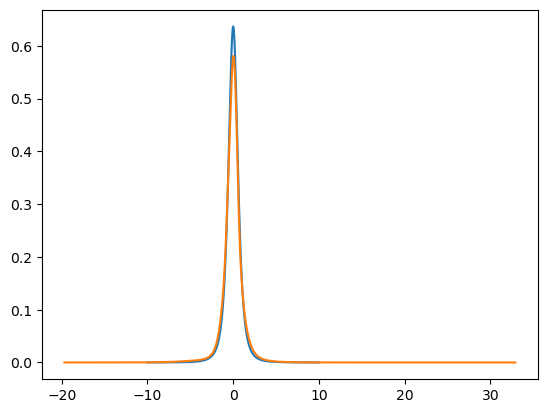

In [224]:
test_model = "scenario_1___nu=3"
test_rep   = 0
date = "2025-07-08"
sim_database[test_model]["replications"][test_rep]["densities"].loc[:, date].plot()
database[0]["df_densities"].loc[:,date].plot()

,2025-07-08,2025-07-09,2025-07-10,2025-07-11,2025-07-12,2025-07-13,2025-07-14,2025-07-15,2025-07-16,2025-07-17,...,2026-04-24,2026-04-25,2026-04-26,2026-04-27,2026-04-28,2026-04-29,2026-04-30,2026-05-01,2026-05-02,2026-05-03
-19.691631,8.298678e-06,0.000015,2.613453e-06,0.000019,0.000013,2.884048e-06,0.000002,4.013539e-06,0.000006,0.000008,...,4.486986e-06,1.527523e-05,0.000009,3.257790e-06,5.260920e-06,6.273025e-06,7.006584e-06,0.000030,2.227591e-06,7.427092e-06
-19.681111,8.319273e-06,0.000015,2.619224e-06,0.000019,0.000013,2.890613e-06,0.000002,4.022387e-06,0.000006,0.000008,...,4.497718e-06,1.531394e-05,0.000009,3.264842e-06,5.272671e-06,6.287704e-06,7.023267e-06,0.000030,2.232691e-06,7.446154e-06
-19.670590,8.339932e-06,0.000015,2.625011e-06,0.000019,0.000013,2.897197e-06,0.000002,4.031260e-06,0.000006,0.000008,...,4.508483e-06,1.535277e-05,0.000009,3.271913e-06,5.284455e-06,6.302426e-06,7.039999e-06,0.000030,2.237807e-06,7.465276e-06
-19.660070,8.360656e-06,0.000015,2.630814e-06,0.000019,0.000013,2.903800e-06,0.000002,4.040158e-06,0.000006,0.000008,...,4.519279e-06,1.539173e-05,0.000009,3.279003e-06,5.296273e-06,6.317191e-06,7.056781e-06,0.000030,2.242937e-06,7.484460e-06
-19.649550,8.381445e-06,0.000015,2.636634e-06,0.000019,0.000013,2.910422e-06,0.000002,4.049081e-06,0.000006,0.000008,...,4.530108e-06,1.543080e-05,0.000009,3.286113e-06,5.308124e-06,6.331999e-06,7.073614e-06,0.000030,2.248081e-06,7.503706e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32.867292,6.548711e-07,0.000001,4.069711e-07,0.000004,0.000001,3.437799e-07,0.000001,7.404151e-07,0.000003,0.000001,...,4.013491e-07,8.696806e-07,0.000002,5.930915e-07,8.796675e-07,6.611436e-07,6.902068e-07,0.000001,2.218498e-07,5.517756e-07
32.877812,6.540243e-07,0.000001,4.064218e-07,0.000004,0.000001,3.433280e-07,0.000001,7.393926e-07,0.000003,0.000001,...,4.008292e-07,8.685913e-07,0.000002,5.922807e-07,8.784512e-07,6.602707e-07,6.893003e-07,0.000001,2.215660e-07,5.510452e-07
32.888333,6.531789e-07,0.000001,4.058734e-07,0.000004,0.000001,3.428768e-07,0.000001,7.383719e-07,0.000003,0.000001,...,4.003101e-07,8.675037e-07,0.000002,5.914713e-07,8.772370e-07,6.593992e-07,6.883953e-07,0.000001,2.212827e-07,5.503160e-07
32.898853,6.523348e-07,0.000001,4.053260e-07,0.000004,0.000001,3.424264e-07,0.000001,7.373530e-07,0.000003,0.000001,...,3.997919e-07,8.664178e-07,0.000002,5.906632e-07,8.760249e-07,6.585291e-07,6.874918e-07,0.000001,2.209999e-07,5.495880e-07
